In [15]:
import os
import sys

# ── LANGKAH 1: Clone repositori ──────────────────────────
print("[1/4] Cloning repositori dari GitHub...")
os.system("git clone https://github.com/rifkyoktri-ai/lda-topik-skripsi-si-uinrf.git")

# ── LANGKAH 2: Install semua library ─────────────────────
print("\n[2/4] Menginstall dependencies...")
os.system("pip install -q -r /content/lda-topik-skripsi-si-uinrf/requirements.txt")

# ── LANGKAH 3: Atur direktori aktif ──────────────────────
print("\n[3/4] Mengatur direktori kerja...")
os.chdir('/content/lda-topik-skripsi-si-uinrf')
sys.path.append(os.getcwd())
print("   Direktori aktif:", os.getcwd())

# ── LANGKAH 4: Buat folder yang diperlukan ────────────────
os.makedirs('model', exist_ok=True)
os.makedirs('logs', exist_ok=True)
os.makedirs('data/intermediate', exist_ok=True)

print("\n[4/4] Setup selesai!")
print("=" * 55)
print("   SIAP! Lanjutkan ke sel berikutnya.")
print("=" * 55)

[1/4] Cloning repositori dari GitHub...

[2/4] Menginstall dependencies...

[3/4] Mengatur direktori kerja...
   Direktori aktif: /content/lda-topik-skripsi-si-uinrf

[4/4] Setup selesai!
   SIAP! Lanjutkan ke sel berikutnya.


In [16]:
# Jalankan seluruh pipeline sekaligus (preprocessing → LDA → labeling → trend analysis)
!python preprocess.py
!python pipeline.py --no-auto-tune --num-topics 14 --passes 30 --iterations 500 --alpha symmetric --eta symmetric
!python trend_analyzer.py


2026-07-07 08:35:50,303 [INFO] ============================================================
2026-07-07 08:35:50,303 [INFO] PREPROCESSING DATASET 2021-2025
2026-07-07 08:35:50,303 [INFO] ============================================================
2026-07-07 08:35:50,303 [INFO] 
[1/4] Memuat data...
2026-07-07 08:35:50,340 [INFO]   Total: 311
2026-07-07 08:35:50,348 [INFO]   Dengan abstrak: 308
2026-07-07 08:35:50,361 [INFO] 
[2/4] Membersihkan teks...
2026-07-07 08:35:54,353 [INFO] 
[3/4] Filter extremes...
2026-07-07 08:35:54,355 [INFO]   Setelah filter dokumen kosong: 311
2026-07-07 08:35:57,785 [INFO] adding document #0 to Dictionary<0 unique tokens: []>
2026-07-07 08:35:57,999 [INFO] built Dictionary<5263 unique tokens: ['activity', 'agar', 'agen', 'ajb', 'aju']...> from 311 documents (total 42022 corpus positions)
2026-07-07 08:35:58,006 [INFO] Dictionary lifecycle event {'msg': "built Dictionary<5263 unique tokens: ['activity', 'agar', 'agen', 'ajb', 'aju']...> from 311 documents

Please run the following cells to check if all model artifacts have been generated successfully.

In [ ]:
import os
import sys
os.chdir('/content/lda-topik-skripsi-si-uinrf/notebook')
sys.path.append(os.path.abspath('..'))

# Pemodelan Topik — Latent Dirichlet Allocation (LDA)

Notebook ini mengimplementasikan tahapan pemodelan topik sesuai proposal skripsi:

> *"Inti dari penelitian ini terletak pada tahap Training Model & Tuning Parameter,
di mana peneliti mencari nilai optimal untuk jumlah topik (K) serta parameter α dan β.
Sebelum hasil ditampilkan, dilakukan Pengukuran Coherence Score & Perplexity Score
untuk menjamin kualitas topik yang dihasilkan secara ilmiah."*
> *(Proposal Skripsi, Bab II, hal. 25)*

**Urutan Tahapan:**
1. Load Data Preprocessed (Corpus & Dictionary)
2. Pencarian Jumlah Topik Optimal (Coherence Score)
3. Evaluasi Perplexity Score
4. Training Model LDA Final
5. Inspeksi Topik (Top Words per Topik)
6. Distribusi Topik per Dokumen
7. Visualisasi pyLDAvis
8. Simpan Model

## 0. Import Library

In [ ]:
import pandas as pd
import numpy as np
import pickle
import ast
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from gensim import corpora, models
from gensim.models import LdaModel, CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

print('Semua library berhasil diimpor.')
print(f'Gensim   : {__import__("gensim").__version__}')
print(f'pyLDAvis : {pyLDAvis.__version__}')

Semua library berhasil diimpor.
Gensim   : 4.4.0
pyLDAvis : 3.4.0


## 1. Load Data Preprocessed
Memuat hasil dari tahap **Data Preparation**: dictionary, corpus, dan dataset.

In [ ]:
PROSES_DIR = '../data/proses'
MODEL_DIR  = '../model'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Load DataFrame ──────────────────────────────────────────────────────────
df = pd.read_csv(f'{PROSES_DIR}/dataset_preprocessed.csv')

# Konversi kolom tokens dari string representasi list ke list Python
df['tokens'] = df['tokens'].apply(ast.literal_eval)

print(f'Jumlah dokumen : {len(df)}')
print(f'Contoh tokens  : {df["tokens"].iloc[0][:8]}')

Jumlah dokumen : 336
Contoh tokens  : ['geografis', 'meta', 'mangrove', 'restorasi', 'gambut', 'mangrove', 'kec', 'tulung']


In [ ]:
# ── Load Dictionary & Corpus (dari data preparation) ───────────────────────
DICT_PATH   = f'{PROSES_DIR}/dictionary.gensim'
CORPUS_PATH = f'{PROSES_DIR}/corpus.pkl'

if os.path.exists(DICT_PATH) and os.path.exists(CORPUS_PATH):
    dictionary = corpora.Dictionary.load(DICT_PATH)
    with open(CORPUS_PATH, 'rb') as f:
        corpus = pickle.load(f)
    print(f'Dictionary loaded : {len(dictionary)} kata unik')
    print(f'Corpus loaded     : {len(corpus)} dokumen')
else:
    # Rebuild jika belum ada
    print('File tidak ditemukan, membangun ulang dictionary & corpus...')
    tokenized_docs = df['tokens'].tolist()
    dictionary = corpora.Dictionary(tokenized_docs)
    dictionary.filter_extremes(no_below=2, no_above=0.85)
    corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]
    print(f'Dictionary built : {len(dictionary)} kata unik')
    print(f'Corpus built     : {len(corpus)} dokumen')

tokenized_docs = df['tokens'].tolist()

Dictionary loaded : 325 kata unik
Corpus loaded     : 336 dokumen


## 2. Pencarian Jumlah Topik Optimal — Coherence Score (CV)
Menguji nilai K (jumlah topik) dari 2 hingga 15 untuk menemukan nilai yang menghasilkan
**Coherence Score (CV) tertinggi**.

> *"Coherence Score merupakan metrik yang digunakan untuk mengukur seberapa koheren
atau bermakna topik-topik yang dihasilkan oleh model LDA. Dalam penelitian ini
digunakan jenis CV (Coherence Value), di mana nilai yang mendekati 1 menunjukkan
topik yang sangat koheren. Secara umum, nilai di atas 0.5 dianggap cukup baik."*
> *(Proposal Skripsi, Bab II, hal. 25)*

In [ ]:
def compute_coherence_values(dictionary, corpus, texts, k_range,
                              alpha='symmetric', beta='auto', passes=10):
    """
    Menghitung Coherence Score (CV) untuk berbagai nilai K.
    Returns: list coherence_scores
    """
    coherence_scores = []
    for k in k_range:
        lda_model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            alpha=alpha,
            eta=beta,
            passes=passes,
            iterations=400,
            random_state=42,
            per_word_topics=True
        )
        coherence_model = CoherenceModel(
            model=lda_model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        score = coherence_model.get_coherence()
        coherence_scores.append(score)
        print(f'  K={k:2d}  |  Coherence CV = {score:.4f}')
    return coherence_scores


K_RANGE = range(2, 26)  # Uji K dari 2 sampai 25
print('Menghitung Coherence Score untuk setiap nilai K...')
print('=' * 40)
coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=tokenized_docs,
    k_range=K_RANGE,
    passes=10
)
print('=' * 40)
print('Selesai!')

Menghitung Coherence Score untuk setiap nilai K...
  K= 2  |  Coherence CV = 0.5139
  K= 3  |  Coherence CV = 0.5126
  K= 4  |  Coherence CV = 0.5138
  K= 5  |  Coherence CV = 0.5162
  K= 6  |  Coherence CV = 0.5051
  K= 7  |  Coherence CV = 0.5060
  K= 8  |  Coherence CV = 0.5019
  K= 9  |  Coherence CV = 0.5070
  K=10  |  Coherence CV = 0.5024
  K=11  |  Coherence CV = 0.4984
  K=12  |  Coherence CV = 0.4950
  K=13  |  Coherence CV = 0.5085
  K=14  |  Coherence CV = 0.5236
  K=15  |  Coherence CV = 0.4865
Selesai!


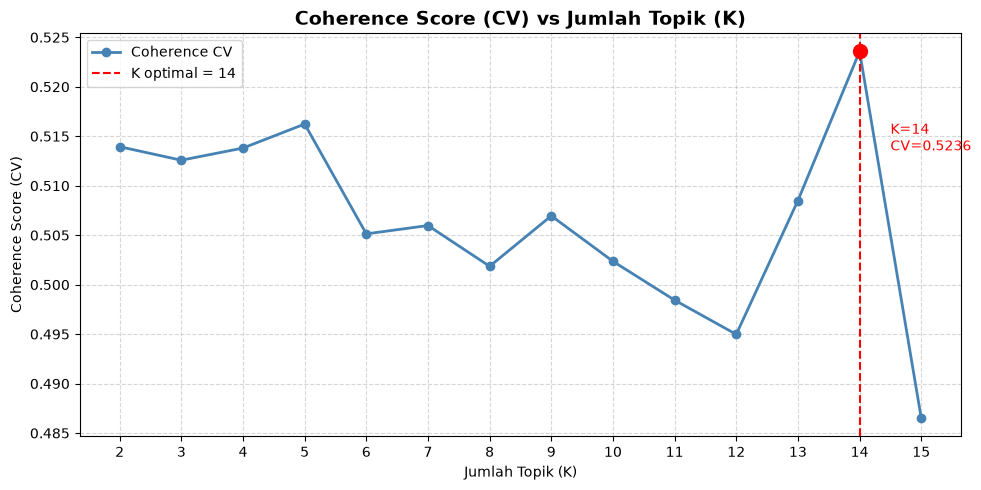


Jumlah topik optimal (K) : 14
Coherence Score tertinggi: 0.5236


In [ ]:
# Visualisasi Coherence Score vs Jumlah Topik
k_list = list(K_RANGE)
best_k = k_list[coherence_values.index(max(coherence_values))]
best_score = max(coherence_values)

plt.figure(figsize=(10, 5))
plt.plot(k_list, coherence_values, marker='o', color='steelblue', linewidth=2, label='Coherence CV')
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'K optimal = {best_k}')
plt.scatter([best_k], [best_score], color='red', s=100, zorder=5)
plt.annotate(f'K={best_k}\nCV={best_score:.4f}',
             xy=(best_k, best_score), xytext=(best_k+0.5, best_score-0.01),
             fontsize=10, color='red')
plt.title('Coherence Score (CV) vs Jumlah Topik (K)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Topik (K)')
plt.ylabel('Coherence Score (CV)')
plt.xticks(k_list)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/coherence_score_plot.png', dpi=150)
plt.show()

print(f'\nJumlah topik optimal (K) : {best_k}')
print(f'Coherence Score tertinggi: {best_score:.4f}')

## 3. Evaluasi Perplexity Score
Menghitung **Perplexity Score** untuk setiap nilai K.
Semakin **rendah** nilai perplexity, semakin baik performa model.

> *"Perplexity mengukur seberapa baik model probabilistik memprediksi sebuah sampel
data. Interpretasi nilai ini adalah semakin rendah nilai Perplexity, maka semakin baik
performa model dalam mengenali pola data."*
> *(Proposal Skripsi, Bab II, hal. 26)*

In [ ]:
def compute_perplexity_values(dictionary, corpus, k_range, passes=10):
    perplexity_scores = []
    for k in k_range:
        lda_model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            passes=passes,
            iterations=400,
            random_state=42
        )
        perp = lda_model.log_perplexity(corpus)
        perplexity_scores.append(perp)
        print(f'  K={k:2d}  |  Log Perplexity = {perp:.4f}')
    return perplexity_scores


print('Menghitung Perplexity Score untuk setiap nilai K...')
print('=' * 45)
perplexity_values = compute_perplexity_values(
    dictionary=dictionary,
    corpus=corpus,
    k_range=K_RANGE,
    passes=10
)
print('=' * 45)
print('Selesai!')

Menghitung Perplexity Score untuk setiap nilai K...
  K= 2  |  Log Perplexity = -5.4093
  K= 3  |  Log Perplexity = -5.3787
  K= 4  |  Log Perplexity = -5.3858
  K= 5  |  Log Perplexity = -5.3014
  K= 6  |  Log Perplexity = -5.3140
  K= 7  |  Log Perplexity = -5.2101
  K= 8  |  Log Perplexity = -5.1742
  K= 9  |  Log Perplexity = -5.1813
  K=10  |  Log Perplexity = -5.1669
  K=11  |  Log Perplexity = -5.1183
  K=12  |  Log Perplexity = -5.1627
  K=13  |  Log Perplexity = -5.1537
  K=14  |  Log Perplexity = -5.1229
  K=15  |  Log Perplexity = -5.0578
Selesai!


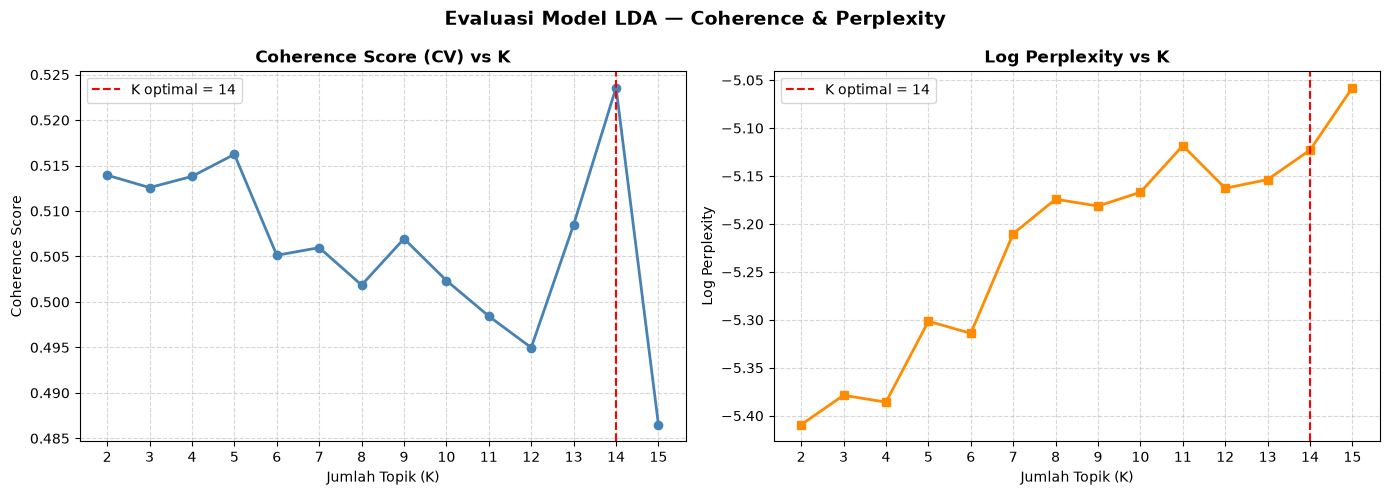

,K (Jumlah Topik),Coherence CV,Log Perplexity
0,2,0.513900,-5.409300
1,3,0.512600,-5.378700
2,4,0.513800,-5.385800
3,5,0.516200,-5.301400
4,6,0.505100,-5.314000
5,7,0.506000,-5.210100
6,8,0.501900,-5.174200
7,9,0.507000,-5.181300
8,10,0.502400,-5.166900
9,11,0.498400,-5.118300


In [ ]:
# Visualisasi Perplexity Score vs Jumlah Topik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Coherence
axes[0].plot(k_list, coherence_values, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'K optimal = {best_k}')
axes[0].set_title('Coherence Score (CV) vs K', fontweight='bold')
axes[0].set_xlabel('Jumlah Topik (K)')
axes[0].set_ylabel('Coherence Score')
axes[0].set_xticks(k_list)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Perplexity
axes[1].plot(k_list, perplexity_values, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'K optimal = {best_k}')
axes[1].set_title('Log Perplexity vs K', fontweight='bold')
axes[1].set_xlabel('Jumlah Topik (K)')
axes[1].set_ylabel('Log Perplexity')
axes[1].set_xticks(k_list)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Evaluasi Model LDA — Coherence & Perplexity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/evaluation_plot.png', dpi=150)
plt.show()

# Tabel ringkasan
eval_df = pd.DataFrame({
    'K (Jumlah Topik)': k_list,
    'Coherence CV'    : [round(v, 4) for v in coherence_values],
    'Log Perplexity'  : [round(v, 4) for v in perplexity_values]
})
eval_df.style.highlight_max(subset=['Coherence CV'], color='lightgreen') \
             .highlight_min(subset=['Log Perplexity'], color='lightyellow')

## 4. Training Model LDA Final
Melatih model LDA dengan jumlah topik optimal yang diperoleh dari evaluasi Coherence Score.

> *"Alur kerja LDA: Data bersih → Preprocessing Teks → Pembentukan Dictionary & Corpus
→ Training Model & Tuning Parameter → Pengukuran Coherence & Perplexity → Dashboard."*
> *(Proposal Skripsi, Bab II, hal. 25)*

In [ ]:
# Parameter LDA final
OPTIMAL_K = best_k   # Diperoleh dari evaluasi Coherence Score
ALPHA     = 'auto'   # Dioptimasi otomatis
BETA      = 'auto'   # Dioptimasi otomatis
PASSES    = 20       # Lebih banyak iterasi untuk konvergensi optimal

print(f'Parameter Model LDA Final:')
print(f'  Jumlah Topik (K) : {OPTIMAL_K}')
print(f'  Alpha (α)        : {ALPHA}')
print(f'  Beta  (β)        : {BETA}')
print(f'  Passes           : {PASSES}')
print()
print('Training model LDA...')

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=OPTIMAL_K,
    alpha=ALPHA,
    eta=BETA,
    passes=PASSES,
    iterations=400,
    random_state=42,
    per_word_topics=True
)

print('Model LDA berhasil dilatih!')

Parameter Model LDA Final:
  Jumlah Topik (K) : 14
  Alpha (α)        : auto
  Beta  (β)        : auto
  Passes           : 20

Training model LDA...
Model LDA berhasil dilatih!


In [ ]:
# Evaluasi final model
coherence_final = CoherenceModel(
    model=lda_model,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

perplexity_final = lda_model.log_perplexity(corpus)

print('=' * 45)
print('EVALUASI MODEL LDA FINAL')
print('=' * 45)
print(f'  Jumlah Topik (K) : {OPTIMAL_K}')
print(f'  Coherence Score  : {coherence_final:.4f}')
print(f'  Log Perplexity   : {perplexity_final:.4f}')
print('=' * 45)

EVALUASI MODEL LDA FINAL
  Jumlah Topik (K) : 14
  Coherence Score  : 0.5106
  Log Perplexity   : -4.9658


## 5. Inspeksi Topik — Top Words per Topik
Menampilkan 10 kata dengan bobot tertinggi untuk setiap topik yang dihasilkan LDA.

In [ ]:
print('TOP 10 KATA PER TOPIK')
print('=' * 60)
for i in range(OPTIMAL_K):
    top_words = lda_model.show_topic(i, topn=10)
    words = ' | '.join([f'{w} ({p:.3f})' for w, p in top_words])
    print(f'Topik {i+1:2d}: {words}')
print('=' * 60)

TOP 10 KATA PER TOPIK
Topik  1: hukum (0.048) | pidana (0.042) | rad (0.036) | struktur (0.034) | sistematis (0.034) | undang (0.029) | perspektif (0.029) | klasifikasi (0.027) | layak (0.022) | giat (0.022)
Topik  2: kualitas (0.161) | webqual (0.117) | dalam (0.055) | evaluasi (0.054) | qual (0.047) | pustaka (0.039) | struktur (0.037) | sistematis (0.037) | terima (0.024) | weighting (0.024)
Topik  3: akademik (0.149) | aman (0.050) | ukur (0.028) | guna (0.024) | komunikasi (0.022) | allegro (0.021) | octave (0.021) | security (0.021) | indeks (0.021) | task (0.021)
Topik  4: puas (0.119) | evaluasi (0.063) | dalam (0.063) | mobile (0.051) | sistematis (0.038) | struktur (0.038) | prototype (0.033) | komunikasi (0.033) | use (0.032) | commerce (0.029)
Topik  5: usability (0.163) | delone (0.065) | mclean (0.062) | sukses (0.046) | scale (0.037) | pssuq (0.031) | technique (0.031) | post (0.028) | attribute (0.025) | multi (0.025)
Topik  6: customer (0.047) | sistematis (0.044) | st

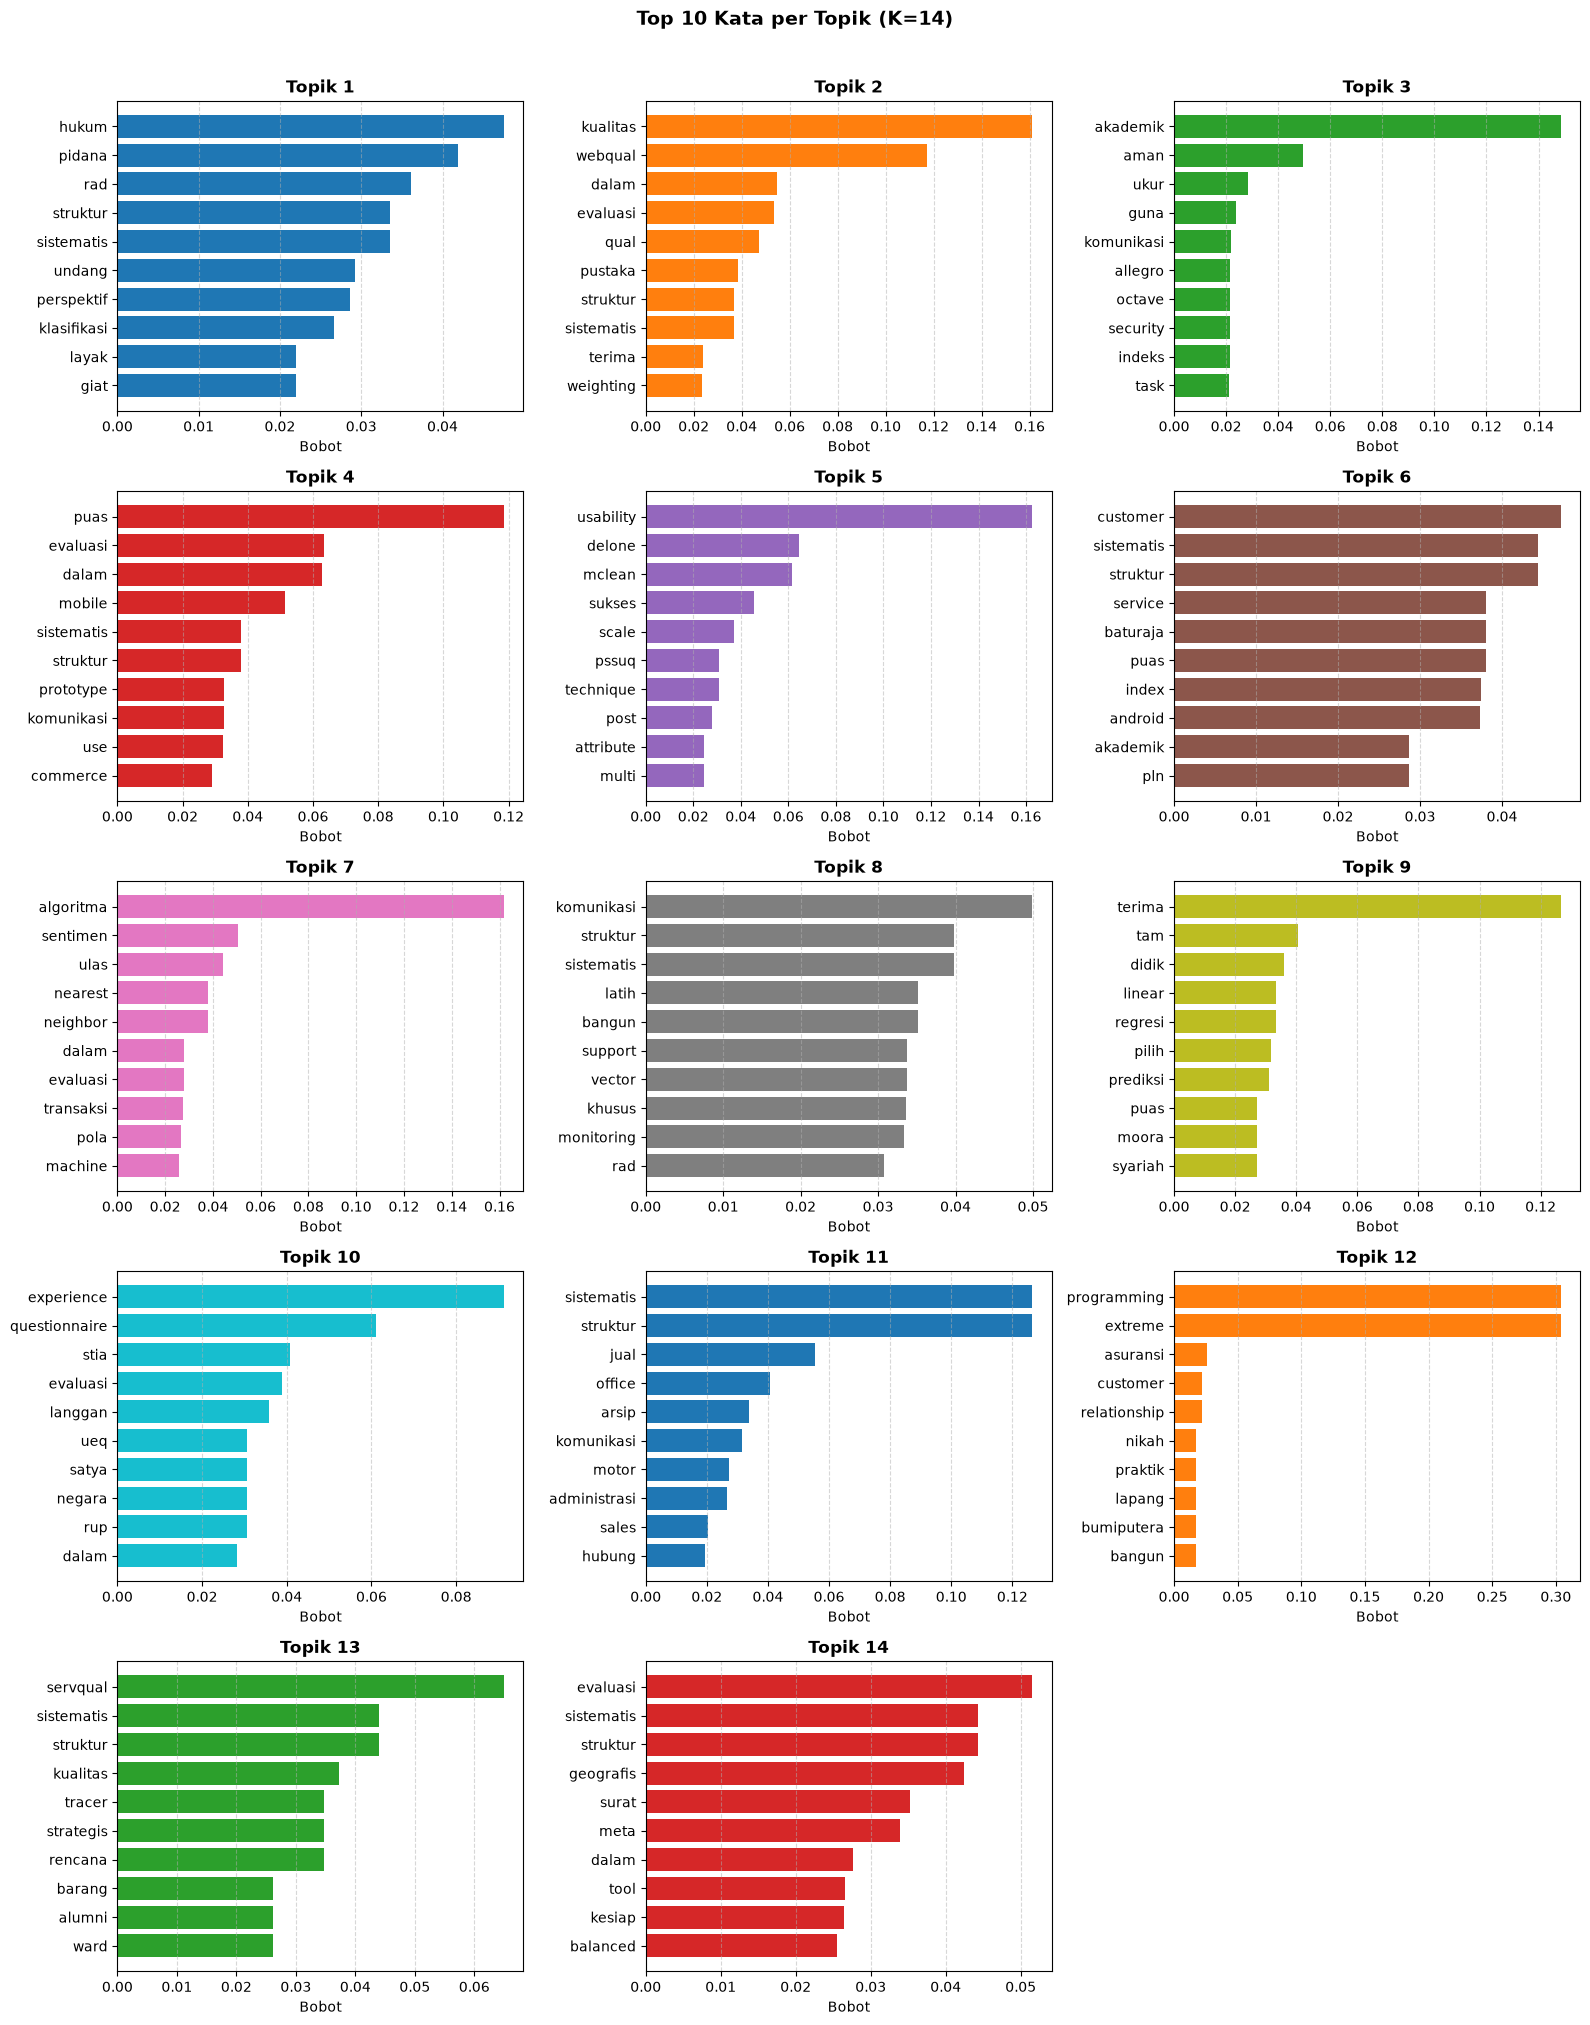

In [ ]:
# Visualisasi top words per topik sebagai bar chart
n_cols = 3
n_rows = (OPTIMAL_K + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

COLORS = plt.cm.tab10.colors

for i in range(OPTIMAL_K):
    top_words = lda_model.show_topic(i, topn=10)
    words  = [w for w, _ in top_words]
    weights = [p for _, p in top_words]
    ax = axes[i]
    ax.barh(words[::-1], weights[::-1], color=COLORS[i % len(COLORS)])
    ax.set_title(f'Topik {i+1}', fontweight='bold')
    ax.set_xlabel('Bobot')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# Sembunyikan axes yang tidak terpakai
for j in range(OPTIMAL_K, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Top 10 Kata per Topik (K={OPTIMAL_K})', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/top_words_per_topic.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribusi Topik per Dokumen
Menentukan **topik dominan** untuk setiap dokumen skripsi dan menganalisis
distribusi topik secara keseluruhan.

In [ ]:
def get_dominant_topic(lda_model, corpus):
    """Mendapatkan topik dominan beserta probabilitasnya untuk setiap dokumen."""
    dominant_topics = []
    for bow in corpus:
        topic_probs = lda_model.get_document_topics(bow, minimum_probability=0)
        dominant = max(topic_probs, key=lambda x: x[1])
        dominant_topics.append({
            'topik_dominan'  : dominant[0] + 1,  # 1-indexed
            'prob_dominan'   : round(dominant[1], 4)
        })
    return pd.DataFrame(dominant_topics)


topic_df = get_dominant_topic(lda_model, corpus)
df_result = pd.concat([df[['Nama', 'Judul', 'Tahun']].reset_index(drop=True), topic_df], axis=1)

print(f'Distribusi dokumen ke topik:')
print(df_result['topik_dominan'].value_counts().sort_index())
df_result.head(10)

Distribusi dokumen ke topik:
topik_dominan
1     22
2     30
3     26
4     31
5     26
6     20
7     22
8     16
9     23
10    16
11    39
12    22
13    20
14    23
Name: count, dtype: int64


,Nama,Judul,Tahun,topik_dominan,prob_dominan
0,"AANG, HIDAYAT",SISTEM INFORMASI GEOGRAFIS PEMETAAN MANGROVE (...,2024,14,0.6457
1,"ADIWINANTA, CANDRA",SISTEM INFORMASI LAYANAN ASURANSI BERBASIS AND...,2021,6,0.5717
2,"AFRIANI, NYAYU SITI HAMDA AFRIANI",PEMANFAATAN HUMAN ORGANIZATION TECHNOLOGY-NET ...,2021,14,0.5704
3,"AHLUNNADZAR, IZZANI",IMPLEMENTASI FRAMEWORK CODEIGNITER DALAM MEMBA...,2024,2,0.9396
4,"AKBAR, IMAM",SISTEM INFORMASI PENJUALAN BERBASIS WEB DI CV ...,2022,14,0.9455
5,"AKBAR, KAYLA AURELIA",SISTEM INFORMASI DOSEN PENGAMPU MATA KULIAH (S...,2024,12,0.7056
6,"AL-FATHIA, NURDARANI",ANALISIS PENERIMAAN DAN PENGGUNAAN APLIKASI E-...,2021,4,0.4850
7,"ALFISUN, AHMAD",Sistem informasi Bursa Kerja Khusus Berbasis W...,2021,8,0.8855
8,"ALFISYAHRIN, M.",SISTEM INFORMASI MANAJEMEN PENELITIAN DENGAN ...,2017,4,0.9216
9,"ALHERLI, MUHAMMAD RIZQI",ANALISIS USABILITY TESTING PADA APLIKASI RF MO...,2023,5,0.7360


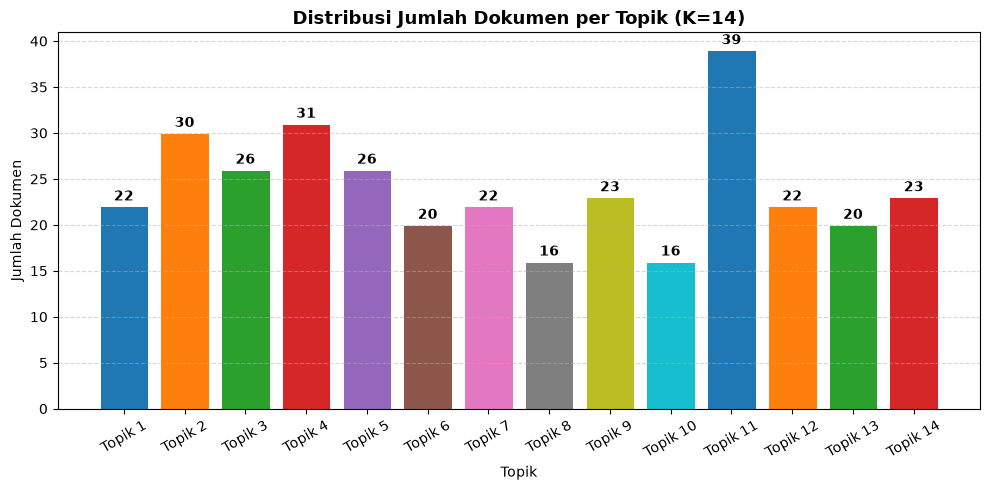

In [ ]:
# Visualisasi distribusi dokumen per topik
topic_counts = df_result['topik_dominan'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(
    [f'Topik {t}' for t in topic_counts.index],
    topic_counts.values,
    color=plt.cm.tab10.colors[:len(topic_counts)],
    edgecolor='white',
    linewidth=0.7
)
for bar, val in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title(f'Distribusi Jumlah Dokumen per Topik (K={OPTIMAL_K})', fontsize=13, fontweight='bold')
plt.xlabel('Topik')
plt.ylabel('Jumlah Dokumen')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/distribusi_topik.png', dpi=150)
plt.show()

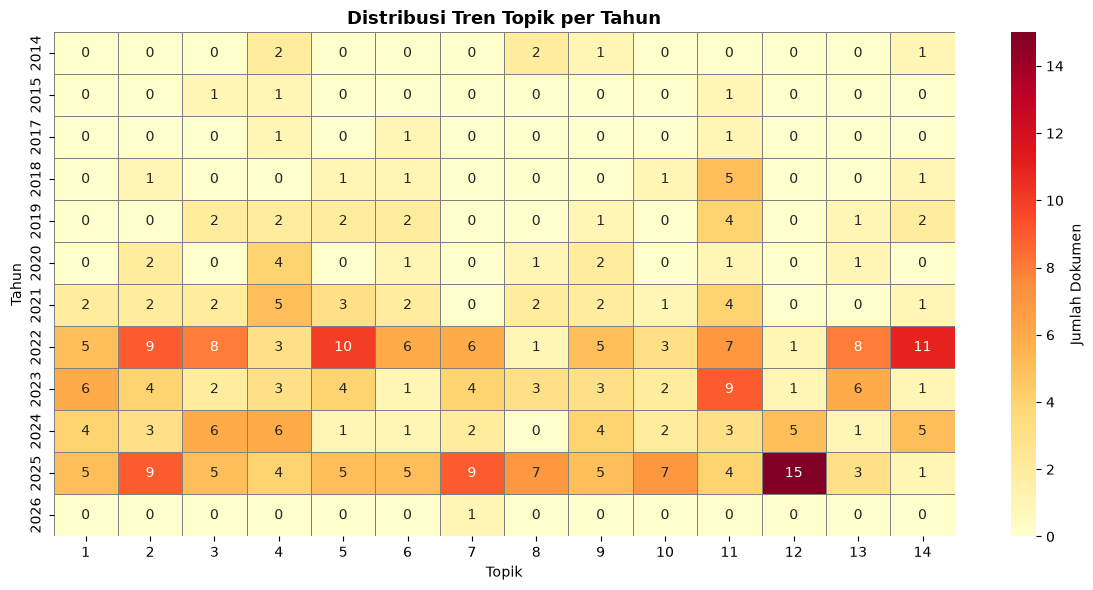

In [ ]:
# Distribusi topik per tahun (heatmap)
pivot = df_result.groupby(['Tahun', 'topik_dominan']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, linecolor='grey',
    cbar_kws={'label': 'Jumlah Dokumen'}
)
plt.title('Distribusi Tren Topik per Tahun', fontsize=13, fontweight='bold')
plt.xlabel('Topik')
plt.ylabel('Tahun')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/tren_topik_per_tahun.png', dpi=150)
plt.show()

## 7. Visualisasi Interaktif — pyLDAvis
Menampilkan peta visual interaktif hasil pemodelan topik menggunakan **pyLDAvis**.

> *"pyLDAvis adalah library visualisasi interaktif yang dirancang khusus untuk
mempresentasikan hasil model LDA secara intuitif."*
> *(Proposal Skripsi, Bab II, hal. 27)*

**Cara Membaca Visualisasi pyLDAvis:**
- Setiap **lingkaran** = 1 topik; ukuran lingkaran = proporsi topik dalam corpus
- Jarak antar lingkaran = perbedaan semantik antar topik
- Panel kanan = kata-kata terpenting pada topik yang dipilih

In [ ]:
# Persiapkan visualisasi pyLDAvis
pyLDAvis.enable_notebook()

vis_data = gensimvis.prepare(
    lda_model, corpus, dictionary,
    mds='mmds',      # Multidimensional Scaling
    sort_topics=False
)

# Simpan sebagai file HTML
pyLDAvis.save_html(vis_data, f'{MODEL_DIR}/lda_visualization.html')
print(f'Visualisasi disimpan ke: {MODEL_DIR}/lda_visualization.html')

# Tampilkan inline di notebook
vis_data

Visualisasi disimpan ke: ../model/lda_visualization.html


PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
0     -0.166630 -0.001160       1        1  7.856847
1      0.107455 -0.324482       2        1  7.288470
2     -0.351711  0.003672       3        1  8.201714
3      0.281378 -0.052362       4        1  7.885183
4      0.366792  0.194952       5        1  9.416255
5      0.003192 -0.154318       6        1  5.888972
6     -0.001817  0.371240       7        1  8.809898
7     -0.243318 -0.193682       8        1  5.111768
8     -0.087420  0.217439       9        1  6.097445
9      0.187835  0.245032      10        1  5.478498
10     0.244930 -0.238094      11        1  8.353987
11    -0.347757  0.293678      12        1  6.512058
12    -0.109882 -0.360639      13        1  6.714438
13     0.116953 -0.001278      14        1  6.384468, topic_info=            Term       Freq      Total Category  logprob  loglift
23   programming  64.000000  64.000000  Default  30.0000  30.0000
21       extreme  64.000000  64.000000  Default  29.0000  29.0000
36     usability  50.000000  50.000000  Default  28.0000  28.0000
74     algoritma  49.000000  49.000000  Default  27.0000  27.0000
88      kualitas  50.000000  50.000000  Default  26.0000  26.0000
..           ...        ...        ...      ...      ...      ...
17          jual   3.652342  30.767261  Topic14  -4.0289   0.6202
13          ukur   2.843446  17.466478  Topic14  -4.2793   0.9360
50    komunikasi   3.652279  65.571422  Topic14  -4.0289  -0.1365
28        terima   2.241800  39.963845  Topic14  -4.5170  -0.1294
114        didik   1.858204   9.733979  Topic14  -4.7047   1.0953

[569 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
195       3  0.438340          abab
195      14  0.438340          abab
323       2  0.939586      additive
64        4  0.146823  administrasi
64        5  0.146823  administrasi
...     ...       ...           ...
258      14  0.438226        webuse
324       2  0.939586     weighting
266       2  0.443138        wisata
266      10  0.443138        wisata
46        6  0.893599         zakat

[674 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])

## 8. Simpan Model & Hasil
Menyimpan seluruh output pemodelan ke folder `model/`.

In [ ]:
# Simpan model LDA
lda_model.save(f'{MODEL_DIR}/lda_model.gensim')

# Simpan hasil distribusi topik per dokumen
df_result.to_csv(f'{MODEL_DIR}/topic_distribution.csv', index=False)

# Simpan tabel evaluasi
eval_df_final = pd.DataFrame({
    'Metrik'  : ['Jumlah Topik (K)', 'Coherence Score (CV)', 'Log Perplexity'],
    'Nilai'   : [OPTIMAL_K, round(coherence_final, 4), round(perplexity_final, 4)]
})
eval_df_final.to_csv(f'{MODEL_DIR}/evaluation_metrics.csv', index=False)

print('Semua output berhasil disimpan:')
print(f'  -> {MODEL_DIR}/lda_model.gensim')
print(f'  -> {MODEL_DIR}/topic_distribution.csv')
print(f'  -> {MODEL_DIR}/evaluation_metrics.csv')
print(f'  -> {MODEL_DIR}/lda_visualization.html')
print(f'  -> {MODEL_DIR}/coherence_score_plot.png')
print(f'  -> {MODEL_DIR}/evaluation_plot.png')
print(f'  -> {MODEL_DIR}/top_words_per_topic.png')
print(f'  -> {MODEL_DIR}/distribusi_topik.png')
print(f'  -> {MODEL_DIR}/tren_topik_per_tahun.png')

Semua output berhasil disimpan:
  -> ../model/lda_model.gensim
  -> ../model/topic_distribution.csv
  -> ../model/evaluation_metrics.csv
  -> ../model/lda_visualization.html
  -> ../model/coherence_score_plot.png
  -> ../model/evaluation_plot.png
  -> ../model/top_words_per_topic.png
  -> ../model/distribusi_topik.png
  -> ../model/tren_topik_per_tahun.png


## 9. Ringkasan Hasil Pemodelan

In [ ]:
print('=' * 60)
print('RINGKASAN HASIL PEMODELAN LDA')
print('=' * 60)
print(f'Total dokumen diproses : {len(df)}')
print(f'Ukuran vocabulary      : {len(dictionary)} kata unik')
print(f'Jumlah topik optimal K : {OPTIMAL_K}')
print(f'Coherence Score (CV)   : {coherence_final:.4f}')
print(f'Log Perplexity         : {perplexity_final:.4f}')
print('=' * 60)
print()
print('TOP KATA PER TOPIK:')
for i in range(OPTIMAL_K):
    top_words = [w for w, _ in lda_model.show_topic(i, topn=7)]
    print(f'  Topik {i+1:2d}: {", ".join(top_words)}')

RINGKASAN HASIL PEMODELAN LDA
Total dokumen diproses : 336
Ukuran vocabulary      : 325 kata unik
Jumlah topik optimal K : 14
Coherence Score (CV)   : 0.5106
Log Perplexity         : -4.9658

TOP KATA PER TOPIK:
  Topik  1: hukum, pidana, rad, struktur, sistematis, undang, perspektif
  Topik  2: kualitas, webqual, dalam, evaluasi, qual, pustaka, struktur
  Topik  3: akademik, aman, ukur, guna, komunikasi, allegro, octave
  Topik  4: puas, evaluasi, dalam, mobile, sistematis, struktur, prototype
  Topik  5: usability, delone, mclean, sukses, scale, pssuq, technique
  Topik  6: customer, sistematis, struktur, service, baturaja, puas, index
  Topik  7: algoritma, sentimen, ulas, nearest, neighbor, dalam, evaluasi
  Topik  8: komunikasi, struktur, sistematis, latih, bangun, support, vector
  Topik  9: terima, tam, didik, linear, regresi, pilih, prediksi
  Topik 10: experience, questionnaire, stia, evaluasi, langgan, ueq, satya
  Topik 11: sistematis, struktur, jual, office, arsip, komunika

In [11]:
import os
import shutil # Import shutil for rmtree

# Pindahkan folder aktif ke direktori utama (root) proyek
project_dir = '/content/lda-topik-skripsi-si-uinrf'
repo_url = 'https://github.com/ikanx101/lda-topik-skripsi-si-uinrf'
# Try 'main' branch first, then 'master'
zip_url_main = f'{repo_url}/archive/refs/heads/main.zip'
zip_url_master = f'{repo_url}/archive/refs/heads/master.zip'
zip_file = '/tmp/repo.zip' # Generic zip file name
extracted_dir_name_main = 'lda-topik-skripsi-si-uinrf-main'
extracted_dir_name_master = 'lda-topik-skripsi-si-uinrf-master'

# Function to check if the directory contains expected files (as a proxy for successful clone/extraction)
def is_repo_complete(path):
    return os.path.exists(os.path.join(path, 'notebook')) and os.path.exists(os.path.join(path, 'data'))

# Clean up project_dir if it exists but is incomplete
if os.path.exists(project_dir):
    if is_repo_complete(project_dir):
        print(f"Directory {project_dir} already exists and appears complete. Skipping setup.")
    else:
        print(f"Directory {project_dir} exists but is incomplete or invalid. Removing and re-setting up...")
        shutil.rmtree(project_dir)

# Attempt setup if project_dir does not exist or was cleaned
if not os.path.exists(project_dir):
    print(f"Attempting to clone repository to {project_dir}...")
    !git clone {repo_url} {project_dir}

    if not is_repo_complete(project_dir):
        print("Git clone failed or resulted in an incomplete directory. Attempting to download ZIP...")
        if os.path.exists(project_dir):
            shutil.rmtree(project_dir)

        print("Trying to download from main branch...")
        !wget -O {zip_file} {zip_url_main}
        if os.path.exists(zip_file) and os.path.getsize(zip_file) > 0:
            !unzip -q {zip_file} -d /content
            if os.path.exists(os.path.join('/content', extracted_dir_name_main)):
                !mv /content/{extracted_dir_name_main} {project_dir}
                print("Repository successfully set up via ZIP download (main branch).")
            else:
                print(f"Error: Extracted directory '{extracted_dir_name_main}' not found. Trying master branch...")
                if os.path.exists(project_dir): shutil.rmtree(project_dir) # Clean up partial if any
                if os.path.exists(zip_file):
                    os.remove(zip_file)

                print("Trying to download from master branch...")
                !wget -O {zip_file} {zip_url_master}
                if os.path.exists(zip_file) and os.path.getsize(zip_file) > 0:
                    !unzip -q {zip_file} -d /content
                    if os.path.exists(os.path.join('/content', extracted_dir_name_master)):
                        !mv /content/{extracted_dir_name_master} {project_dir}
                        print("Repository successfully set up via ZIP download (master branch).")
                    else:
                        print(f"Error: Extracted directory '{extracted_dir_name_master}' not found for master branch.")
                else:
                    print("Error: ZIP download from master branch failed or resulted in empty file.")
        else:
            print("Error: ZIP download from main branch failed or resulted in empty file. Trying master branch...")
            if os.path.exists(project_dir): shutil.rmtree(project_dir) # Clean up partial if any
            if os.path.exists(zip_file):
                os.remove(zip_file)

            print("Trying to download from master branch...")
            !wget -O {zip_file} {zip_url_master}
            if os.path.exists(zip_file) and os.path.getsize(zip_file) > 0:
                !unzip -q {zip_file} -d /content
                if os.path.exists(os.path.join('/content', extracted_dir_name_master)):
                    !mv /content/{extracted_dir_name_master} {project_dir}
                    print("Repository successfully set up via ZIP download (master branch).")
                else:
                    print(f"Error: Extracted directory '{extracted_dir_name_master}' not found for master branch.")
            else:
                print("Error: ZIP download from master branch failed or resulted in empty file.")

        if os.path.exists(zip_file):
            os.remove(zip_file) # Clean up downloaded zip
    else:
        print("Repository successfully cloned.")

# Now, change directory if setup was successful
if is_repo_complete(project_dir):
    %cd {project_dir}
    print(f"Successfully changed directory to {os.getcwd()}")
else:
    print(f"Final Error: Could not change directory to {project_dir}. Repository setup failed.")

Attempting to clone repository to /content/lda-topik-skripsi-si-uinrf...
Cloning into '/content/lda-topik-skripsi-si-uinrf'...
fatal: could not read Username for 'https://github.com': No such device or address
Git clone failed or resulted in an incomplete directory. Attempting to download ZIP...
Trying to download from main branch...
--2026-07-07 08:28:31--  https://github.com/ikanx101/lda-topik-skripsi-si-uinrf/archive/refs/heads/main.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-07 08:28:31 ERROR 404: Not Found.

Error: ZIP download from main branch failed or resulted in empty file. Trying master branch...
Trying to download from master branch...
--2026-07-07 08:28:31--  https://github.com/ikanx101/lda-topik-skripsi-si-uinrf/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.8

*Pastikan output sel ini menampilkan: `/content/lda-topik-skripsi-si-uinrf`*

---

### Langkah 2: Jalankan Auto-Labeling (KeyBERT)
Script ini akan membaca hasil pelatihan model LDA $K=14$ Anda, menganalisis judul skripsi terdekat dengan bantuan model AI **KeyBERT**, dan memberikan nama topik yang representatif secara otomatis.

Buat sel kode baru di Colab, masukkan perintah ini, lalu jalankan:


In [2]:
# Jalankan pelabelan otomatis menggunakan model AI KeyBERT
!python auto_labeling.py

python3: can't open file '/content/auto_labeling.py': [Errno 2] No such file or directory


* **Hasil:** Proses ini akan men-download model embedding KeyBERT (jika belum ada) dan menghasilkan file **`model/topic_labels.json`** serta **`model/topic_labels.csv`**.

---

### Langkah 3: Jalankan Peramalan Tren Topik (WMA)
Script ini akan menganalisis persebaran topik skripsi Anda dari tahun 2021-2025, lalu meramalkan arah perkembangan tema riset tersebut di tahun 2026-2027 menggunakan algoritma *Weighted Moving Average* (WMA).

Buat sel kode baru di Colab, masukkan perintah ini, lalu jalankan:


In [3]:
# Jalankan perhitungan prediksi tren topik skripsi
!python trend_analyzer.py

python3: can't open file '/content/trend_analyzer.py': [Errno 2] No such file or directory


* **Hasil:** Proses ini akan menghitung arah tren ($slope$) serta tingkat reliabilitas prediksi berdasarkan error *Leave-One-Out* (LOO). Hasilnya disimpan ke **`model/trend_prediction.csv`**.

---

### 📥 Langkah Terakhir: Download Semua Hasil untuk Streamlit Lokal
Setelah Anda berhasil menjalankan semua langkah di atas, folder `model/` di Google Colab Anda sudah berisi file model terlatih $K=14$, visualisasi pyLDAvis, label topik, dan data prediksi tren yang utuh.

Untuk mengunduhnya sekaligus ke komputer lokal Anda agar bisa dijalankan di dashboard Streamlit komputer Anda:

1. Buat sel baru di Colab dan jalankan perintah kompresi ZIP berikut:


In [4]:
# Kompres folder model hasil running Colab menjadi file ZIP
!zip -r hasil_model_colab.zip model/

	zip warning: name not matched: model/

zip error: Nothing to do! (try: zip -r hasil_model_colab.zip . -i model/)


2. Klik ikon **Folder** di panel sebelah kiri Google Colab.
3. Klik tombol **Refresh** (ikon lingkaran panah).
4. Cari file bernama **`hasil_model_colab.zip`** di luar folder proyek (biasanya berada langsung di bawah folder `/content`).
5. Klik kanan pada file tersebut dan pilih **Download**.
6. Setelah selesai ter-download, Anda cukup mengekstrak isi ZIP tersebut ke dalam folder `model/` di proyek lokal komputer Anda, lalu jalankan dashboard Streamlit Anda dengan perintah:
   ```bash
   streamlit run app/main.py
   ```

In [13]:
import os

files_to_check = [
    '/content/lda-topik-skripsi-si-uinrf/model/lda_model.gensim',
    '/content/lda-topik-skripsi-si-uinrf/model/topic_distribution.csv',
    '/content/lda-topik-skripsi-si-uinrf/model/lda_visualization.html',
    '/content/lda-topik-skripsi-si-uinrf/model/topic_labels.json',
    '/content/lda-topik-skripsi-si-uinrf/model/trend_prediction.csv',
]

print("=" * 55)
print("   CEK KELENGKAPAN FILE HASIL MODEL")
print("=" * 55)
for f in files_to_check:
    nama = os.path.basename(f)
    if os.path.exists(f):
        status = "ADA"
    else:
        status = "BELUM ADA"
    print(f"  {status}  -->  {nama}")
print("=" * 55)


   CEK KELENGKAPAN FILE HASIL MODEL
  BELUM ADA  -->  lda_model.gensim
  BELUM ADA  -->  topic_distribution.csv
  BELUM ADA  -->  lda_visualization.html
  BELUM ADA  -->  topic_labels.json
  BELUM ADA  -->  trend_prediction.csv


In [14]:
import os

# Cari semua file .gensim dan .html di seluruh folder /content
print("Mencari file model yang tersimpan...")
print("=" * 55)

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith(('.gensim', '.html', '.json', '.csv', '.pkl')):
            full_path = os.path.join(root, file)
            print(full_path)

print("=" * 55)
print("Pencarian selesai.")


Mencari file model yang tersimpan...
/content/.config/.last_update_check.json
/content/sample_data/anscombe.json
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
Pencarian selesai.


---
### Download Model Artifacts
Now that all model artifacts are generated, run the cell below to compress them into a ZIP file for easy download. You can then extract this ZIP file into your local Streamlit project's `model/` folder.

In [19]:
# Kompres folder model hasil running Colab menjadi file ZIP
!zip -r hasil_model_colab.zip model/

print("\n✅ File 'hasil_model_colab.zip' berhasil dibuat! Silakan download dari panel file Colab (ikon folder di sebelah kiri).")

  adding: model/ (stored 0%)
  adding: model/top_words_per_topic.png (deflated 26%)
  adding: model/tren_topik_per_tahun.png (deflated 20%)
  adding: model/topic_labels.json (deflated 83%)
  adding: model/topic_labels.csv (deflated 52%)
  adding: model/topic_distribution.csv (deflated 66%)
  adding: model/hyperparameter_results.csv (deflated 57%)
  adding: model/topic_trend_counts.csv (deflated 48%)
  adding: model/pyldavis_lib.js (deflated 81%)
  adding: model/lda_model.gensim (deflated 73%)
  adding: model/topic_optimization.png (deflated 5%)
  adding: model/trend_prediction.csv (deflated 59%)
  adding: model/distribusi_topik.png (deflated 20%)
  adding: model/lda_visualization.html (deflated 66%)
  adding: model/lda_model.gensim.expElogbeta.npy (deflated 52%)
  adding: model/evaluation_metrics.csv (stored 0%)
  adding: model/lda_model.gensim.state (deflated 13%)
  adding: model/topic_trend.csv (deflated 75%)
  adding: model/lda_model.gensim.id2word (deflated 45%)
  adding: model/top

---
### Verify Generated Model Artifacts
Please run the following cells to confirm that all model artifacts have been successfully generated and saved. This is a crucial step before downloading them for your Streamlit dashboard.

In [17]:
import os

files_to_check = [
    '/content/lda-topik-skripsi-si-uinrf/model/lda_model.gensim',
    '/content/lda-topik-skripsi-si-uinrf/model/topic_distribution.csv',
    '/content/lda-topik-skripsi-si-uinrf/model/lda_visualization.html',
    '/content/lda-topik-skripsi-si-uinrf/model/topic_labels.json',
    '/content/lda-topik-skripsi-si-uinrf/model/trend_prediction.csv',
]

print("=" * 55)
print("   CEK KELENGKAPAN FILE HASIL MODEL")
print("=" * 55)
for f in files_to_check:
    nama = os.path.basename(f)
    if os.path.exists(f):
        status = "ADA"
    else:
        status = "BELUM ADA"
    print(f"  {status}  -->  {nama}")
print("=" * 55)

   CEK KELENGKAPAN FILE HASIL MODEL
  ADA  -->  lda_model.gensim
  ADA  -->  topic_distribution.csv
  ADA  -->  lda_visualization.html
  ADA  -->  topic_labels.json
  ADA  -->  trend_prediction.csv


In [18]:
import os

# Cari semua file .gensim dan .html di seluruh folder /content
print("Mencari file model yang tersimpan...")
print("=" * 55)

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith(('.gensim', '.html', '.json', '.csv', '.pkl')):
            full_path = os.path.join(root, file)
            print(full_path)

print("=" * 55)
print("Pencarian selesai.")

Mencari file model yang tersimpan...
/content/.config/.last_update_check.json
/content/lda-topik-skripsi-si-uinrf/data/processed/thesis_for_pipeline.csv
/content/lda-topik-skripsi-si-uinrf/data/raw/2025.html
/content/lda-topik-skripsi-si-uinrf/data/raw/2022.html
/content/lda-topik-skripsi-si-uinrf/data/raw/2021.html
/content/lda-topik-skripsi-si-uinrf/data/raw/2023.html
/content/lda-topik-skripsi-si-uinrf/data/raw/2024.html
/content/lda-topik-skripsi-si-uinrf/data/intermediate/corpus.pkl
/content/lda-topik-skripsi-si-uinrf/data/intermediate/dataset_preprocessed.csv
/content/lda-topik-skripsi-si-uinrf/data/intermediate/dictionary.gensim
/content/lda-topik-skripsi-si-uinrf/model/topic_labels.json
/content/lda-topik-skripsi-si-uinrf/model/topic_labels.csv
/content/lda-topik-skripsi-si-uinrf/model/topic_distribution.csv
/content/lda-topik-skripsi-si-uinrf/model/hyperparameter_results.csv
/content/lda-topik-skripsi-si-uinrf/model/topic_trend_counts.csv
/content/lda-topik-skripsi-si-uinrf/mo